# Phase 5: Exploratory Data Analysis

## Objective

The purpose of this phase is to explore the cleaned Walmart sales dataset using descriptive statistics and visualisations.

This phase will investigate:

- The distribution of weekly sales
- Potential outliers
- Sales performance across stores
- Holiday and non-holiday sales
- Sales trends over time
- Yearly and monthly sales patterns
- Relationships between numerical features
- Correlations with weekly sales
- Important business insights for modelling

No machine learning model will be trained during this phase.

## Exploratory Analysis Approach

Exploratory Data Analysis helps reveal patterns and relationships that may not be obvious from summary tables alone.

The analysis will combine:

- Univariate analysis to examine individual variables
- Bivariate analysis to compare two variables
- Multivariate analysis to study relationships across several variables
- Time-series analysis to examine changes in weekly sales over time

Potential outliers will be investigated rather than removed automatically because unusually high sales may represent genuine holiday or promotional activity.

In [1]:
# Importing the lib.

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Setting a simple visual style

sns.set_theme(style="whitegrid")

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}",
)

print("Visualisation settings applied.")

Visualisation settings applied.


In [3]:
# Defining the project paths

current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name.lower() == "notebooks"
    else current_directory
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "walmart_cleaned.csv"
)

images_path = (
    project_root
    / "reports"
    / "images"
)

images_path.mkdir(
    parents=True,
    exist_ok=True,
)

print("Processed dataset:", processed_data_path)
print("Images directory:", images_path)

Processed dataset: c:\Users\Udoch\walmart-sales-regression\data\processed\walmart_cleaned.csv
Images directory: c:\Users\Udoch\walmart-sales-regression\reports\images


In [4]:
# Confirming that the cleaned file exists

if not processed_data_path.exists():
    raise FileNotFoundError(
        f"The cleaned dataset was not found at: "
        f"{processed_data_path}"
    )

print("Cleaned dataset found successfully.")

Cleaned dataset found successfully.


In [5]:
# Loading the cleaned dataset

df = pd.read_csv(
    processed_data_path,
    parse_dates=["date"],
)

print("Cleaned dataset loaded successfully.")
print("Dataset shape:", df.shape)

Cleaned dataset loaded successfully.
Dataset shape: (6435, 8)


## Dataset Preview

The first few rows are inspected to confirm that the cleaned dataset loaded correctly and that the standardised column names are available.

In [6]:
df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,2,2010-02-05,"2,136,989.46",0,40.19,2.57,210.75,8.32
2,3,2010-02-05,"461,622.22",0,45.71,2.57,214.42,7.37
3,4,2010-02-05,"2,135,143.87",0,43.76,2.60,126.44,8.62
4,5,2010-02-05,"317,173.10",0,39.70,2.57,211.65,6.57


In [7]:
# Confirming the dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[us]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


### Dataset Structure Interpretation

The cleaned dataset contains 6,435 observations and 8 columns.

The `date` column is stored as datetime, while weekly sales and the economic variables are numerical.

`store` and `holiday_flag` are stored as integers but represent categorical information.

## Temporary Time Features

Additional calendar variables are created from the `date` column to support time-based analysis.

These variables are used only for exploration at this stage.

In [8]:
# Creating useful time features for analysis

eda_df = df.copy()

eda_df["year"] = eda_df["date"].dt.year
eda_df["month"] = eda_df["date"].dt.month
eda_df["month_name"] = eda_df["date"].dt.month_name()
eda_df["week_of_year"] = (
    eda_df["date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)

eda_df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,year,month,month_name,week_of_year
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2010,2,February,5
1,2,2010-02-05,"2,136,989.46",0,40.19,2.57,210.75,8.32,2010,2,February,5
2,3,2010-02-05,"461,622.22",0,45.71,2.57,214.42,7.37,2010,2,February,5
3,4,2010-02-05,"2,135,143.87",0,43.76,2.60,126.44,8.62,2010,2,February,5
4,5,2010-02-05,"317,173.10",0,39.70,2.57,211.65,6.57,2010,2,February,5


## Distribution of Weekly Sales

A histogram shows how frequently different weekly-sales values occur.

The density curve helps reveal whether the target variable is symmetric, skewed, or contains multiple peaks.

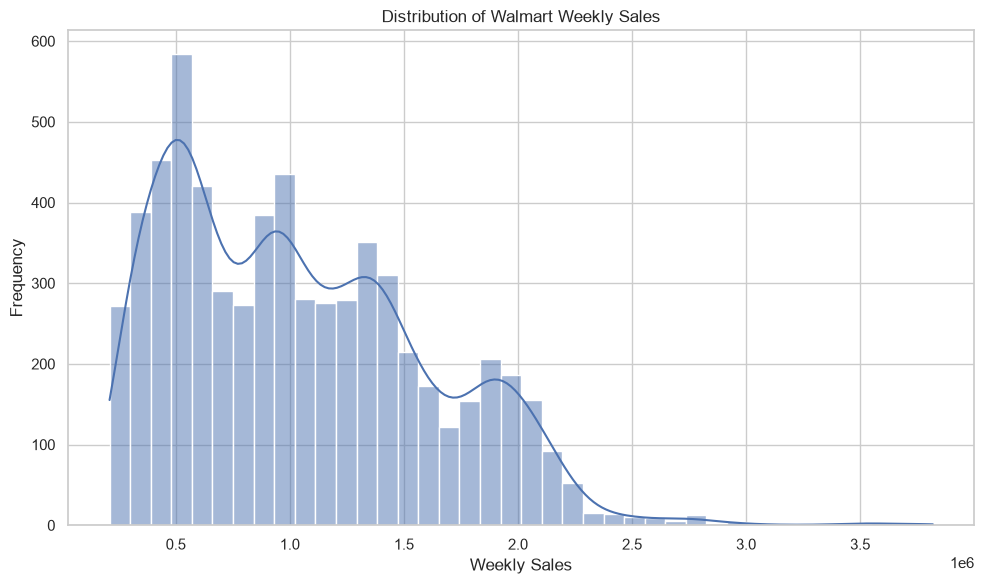

In [9]:
# Analysing the target distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="weekly_sales",
    bins=40,
    kde=True,
)

plt.title(
    "Distribution of Walmart Weekly Sales"
)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    images_path / "weekly_sales_distribution.png",
    bbox_inches="tight",
)

plt.show()

### Weekly Sales Distribution Interpretation

The distribution of `Weekly_Sales` is not symmetrical i.e **not normally distributed**. It is **positively skewed (right-skewed)** because the distribution has a long tail extending towards the higher weekly-sales values.

Most weekly-sales observations are concentrated between approximately **300,000 and 2,000,000**, while relatively few observations exceed **2,500,000**.

The distribution also contains several visible peaks. This may indicate differences in sales patterns between stores, store sizes, seasons, holiday periods, or promotional weeks.

A small number of observations have exceptionally high weekly sales, reaching above **3,000,000**. These values should not be removed automatically because they may represent genuine sales increases caused by holidays, promotions, or high-performing stores.

The right-skewed distribution and the presence of high sales values will be considered during feature engineering, model selection, and model evaluation.

In [10]:
# Calculating the target skewness

weekly_sales_skewness = (
    eda_df["weekly_sales"].skew()
)

print(
    "Weekly sales skewness:",
    round(weekly_sales_skewness, 3),
)

Weekly sales skewness: 0.668


### Skewness Interpretation

The `weekly_sales` variable has a skewness value of **0.668**.

Because the value is positive, the distribution is **right-skewed**. This means most weekly sales observations are concentrated around the lower and middle sales ranges, while a smaller number of very high sales values extend the distribution to the right.

The value of **0.668** suggests a **moderate positive skew** rather than a severe skew.

This result supports the pattern observed in the histogram, where a longer upper tail and several high-sales observations were visible.

These high values should not be removed automatically because they may represent genuine holiday periods, seasonal peaks, promotions, or high-performing stores.

## Weekly-Sales Boxplot

A boxplot helps identify the median, interquartile range, and observations located beyond the usual range.

Values outside the whiskers are potential outliers, but they are not automatically errors.

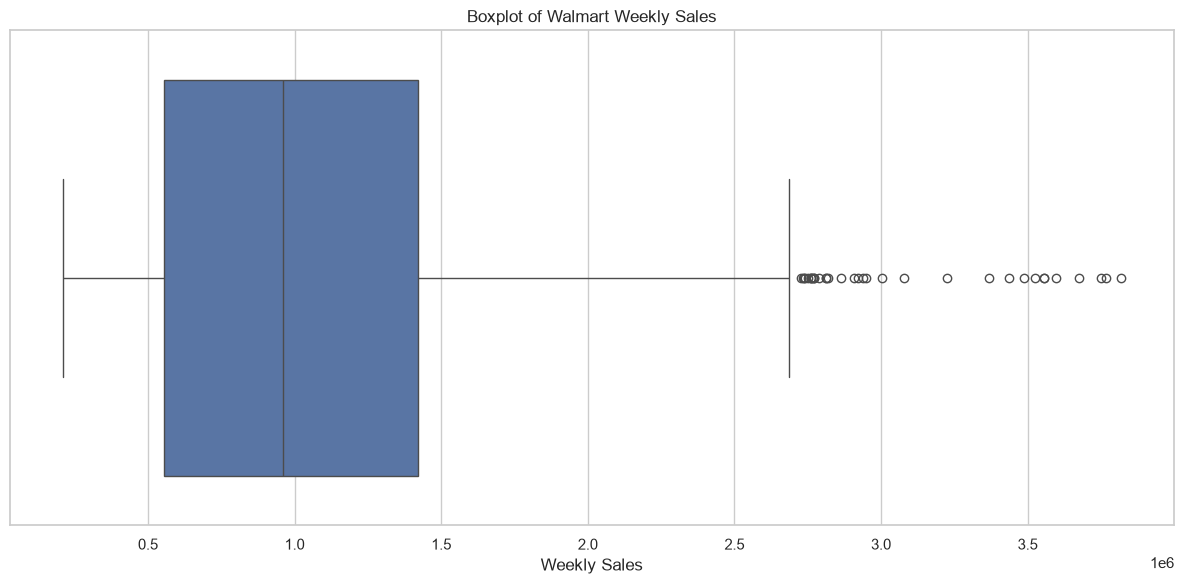

In [11]:
# Creating a weekly-sales boxplot

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=eda_df,
    x="weekly_sales",
)

plt.title(
    "Boxplot of Walmart Weekly Sales"
)
plt.xlabel("Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "weekly_sales_boxplot.png",
    bbox_inches="tight",
)

plt.show()

### Weekly-Sales Boxplot Interpretation

The boxplot shows that most weekly sales values are concentrated within the interquartile range (IQR), while several observations appear beyond the upper whisker.

These observations are considered potential outliers because they are substantially higher than the majority of weekly sales values.

The presence of these high sales values is consistent with the histogram and the positive skewness value (**0.668**), which indicated a moderately right-skewed distribution.

These observations are likely to represent genuine business events rather than data entry errors, such as:

- Holiday shopping periods
- Promotional campaigns
- Seasonal sales peaks
- High-performing Walmart stores

Since these values may contain important business information, they will be retained during exploratory data analysis. Any decision to remove or transform them will only be made if later modelling shows that they negatively affect model performance.

In [12]:
# Quantifing target outliers using the IQR method

q1 = eda_df["weekly_sales"].quantile(0.25)
q3 = eda_df["weekly_sales"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

sales_outliers = eda_df[
    (eda_df["weekly_sales"] < lower_bound)
    | (eda_df["weekly_sales"] > upper_bound)
]

print("First quartile:", q1)
print("Third quartile:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential sales outliers:", len(sales_outliers))

First quartile: 553350.105
Third quartile: 1420158.66
IQR: 866808.5549999999
Lower bound: -746862.7275
Upper bound: 2720371.4924999997
Potential sales outliers: 34


In [13]:
outlier_percentage = (
    len(sales_outliers)
    / len(eda_df)
    * 100
)

print(
    "Potential outlier percentage:",
    round(outlier_percentage, 2),
    "%",
)

Potential outlier percentage: 0.53 %


### IQR Outlier Analysis Interpretation

The Interquartile Range (IQR) method was used to identify potential outliers in the weekly sales data.

**Results:**

- First Quartile (Q1): **553,350.11**
- Third Quartile (Q3): **1,420,158.66**
- Interquartile Range (IQR): **866,808.55**
- Lower Bound: **-746,862.73**
- Upper Bound: **2,720,371.49**
- Potential Outliers: **34 observations**
- Potential Outlier Percentage: **0.53%**

The lower bound is negative, while weekly sales cannot be negative. Therefore, all identified outliers occur above the upper bound and represent unusually high weekly sales values.

Only **34 observations (0.53%)** were identified as potential outliers, indicating that extreme sales values are very rare within the dataset.

These observations are likely to represent genuine business events such as:

- Holiday shopping periods
- Promotional campaigns
- Seasonal demand peaks
- High-performing Walmart stores

Since less than **1%** of the dataset is identified as potential outliers, these records will be retained for model development. Removing them could eliminate valuable business information and reduce the model's ability to learn genuine high-sales scenarios.

The IQR analysis is consistent with the histogram, skewness analysis, and boxplot, all of which indicate a moderately right-skewed distribution with a small number of exceptionally high weekly sales values.

## Average Weekly Sales by Store

Comparing average weekly sales across stores helps identify consistently high-performing and low-performing locations.

In [14]:
# Comparing average sales across stores

store_sales = (
    eda_df
    .groupby("store", as_index=False)
    ["weekly_sales"]
    .mean()
    .sort_values(
        "weekly_sales",
        ascending=False,
    )
)

store_sales.head(10)

,store,weekly_sales
19,20,"2,107,676.87"
3,4,"2,094,712.96"
13,14,"2,020,978.40"
12,13,"2,003,620.31"
1,2,"1,925,751.34"
9,10,"1,899,424.57"
26,27,"1,775,216.20"
5,6,"1,564,728.19"
0,1,"1,555,264.40"
38,39,"1,450,668.13"


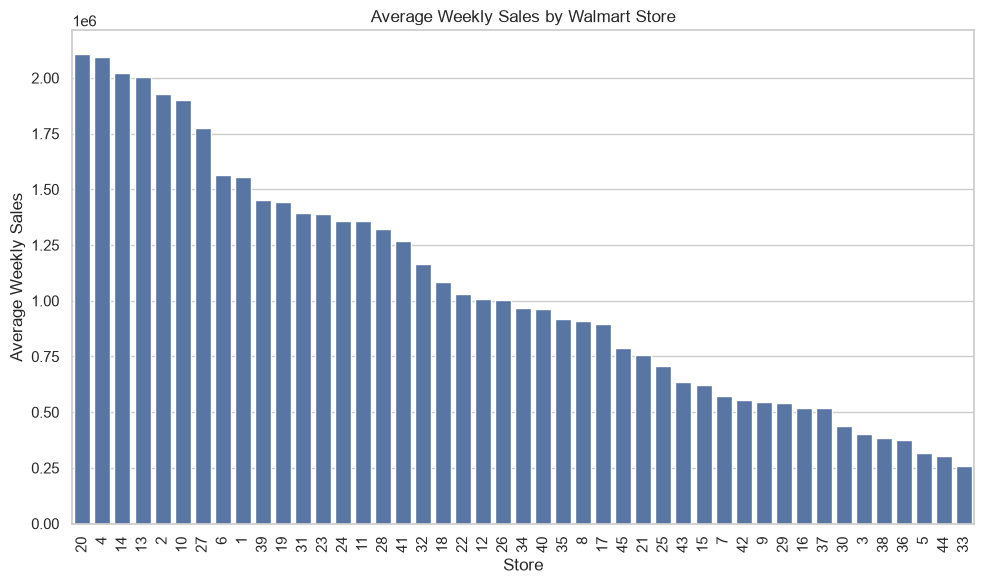

In [15]:
# Creating the chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=store_sales,
    x="store",
    y="weekly_sales",
    order=store_sales["store"],
)

plt.title(
    "Average Weekly Sales by Walmart Store"
)
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    images_path / "average_sales_by_store.png",
    bbox_inches="tight",
)

plt.show()

### Average Weekly Sales by Store Interpretation

The analysis shows substantial differences in average weekly sales across the 45 Walmart stores.

The highest-performing stores include:

- **Store 20:** approximately **2.11 million**
- **Store 4:** approximately **2.09 million**
- **Store 14:** approximately **2.02 million**
- **Store 13:** approximately **2.00 million**
- **Store 2:** approximately **1.93 million**

Other strong-performing stores include Stores 10, 27, 6, 1, and 39.

The bar chart is arranged from the highest to the lowest average weekly sales. It confirms that store performance is not evenly distributed. A small group of stores consistently records much higher average sales, while several stores operate at considerably lower sales levels.

This large difference between stores may be connected to factors such as:

- Store size
- Geographic location
- Local population and customer demand
- Product availability
- Regional economic conditions
- Competition
- Store-specific promotions

However, these possible explanations cannot be confirmed from the available dataset because variables such as store size and location are not included.

The result shows that `store` contains important predictive information. Although it is stored as a number, it represents a store identifier rather than a continuous measurement. Therefore, it should be treated as a **categorical feature** during preprocessing.

This also helps explain the multiple peaks observed in the weekly-sales histogram: different stores appear to have different normal sales ranges.

In [16]:
# Displaying the top and bottom stores

top_five_stores = store_sales.head(5)
bottom_five_stores = store_sales.tail(5)

print("Top five stores:")
display(top_five_stores)

print("Bottom five stores:")
display(bottom_five_stores)

Top five stores:


,store,weekly_sales
19,20,"2,107,676.87"
3,4,"2,094,712.96"
13,14,"2,020,978.40"
12,13,"2,003,620.31"
1,2,"1,925,751.34"


Bottom five stores:


,store,weekly_sales
37,38,"385,731.65"
35,36,"373,511.99"
4,5,"318,011.81"
43,44,"302,748.87"
32,33,"259,861.69"


### Top and Bottom Performing Stores Interpretation

The analysis identifies the stores with the highest and lowest average weekly sales.

#### Top Five Stores

The highest-performing stores are:

| Rank | Store | Average Weekly Sales |
|------|-------|---------------------:|
| 1 | Store 20 | 2,107,676.87 |
| 2 | Store 4 | 2,094,712.96 |
| 3 | Store 14 | 2,020,978.40 |
| 4 | Store 13 | 2,003,620.31 |
| 5 | Store 2 | 1,925,751.34 |

These stores consistently generate the highest average weekly sales in the dataset, suggesting stronger business performance than the majority of stores.

#### Bottom Five Stores

The lowest-performing stores are:

| Rank | Store | Average Weekly Sales |
|------|-------|---------------------:|
| 1 | Store 38 | 385,731.65 |
| 2 | Store 36 | 373,511.99 |
| 3 | Store 5 | 318,011.81 |
| 4 | Store 44 | 302,748.87 |
| 5 | Store 33 | 259,861.69 |

These stores record considerably lower average weekly sales compared with the highest-performing stores.

The difference between the best and worst-performing stores is substantial. For example, Store 20 records an average weekly sales value of approximately **£2.11 million**, while Store 33 averages only **£0.26 million**. This indicates that store performance varies greatly across the Walmart network.

The observed differences may be influenced by factors such as store size, customer demand, location, regional economic conditions, local competition, and promotional activities. However, these factors are not directly available in the dataset and therefore cannot be confirmed from this analysis alone.

Overall, this result provides further evidence that the **store** variable contains valuable predictive information and should be retained as an important feature when building the weekly sales prediction model.

## Holiday and Non-Holiday Sales

This analysis compares weekly sales between holiday weeks and ordinary weeks.

Holiday periods may create temporary increases in customer demand.

In [17]:
# Comparing holiday and non-holiday sales

holiday_sales_summary = (
    eda_df
    .groupby("holiday_flag")
    ["weekly_sales"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        total="sum",
    )
)

holiday_sales_summary

,count,mean,median,total
holiday_flag,,,,
0,5985,"1,041,256.38","956,211.20","6,231,919,435.55"
1,450,"1,122,887.89","1,018,538.04","505,299,551.56"


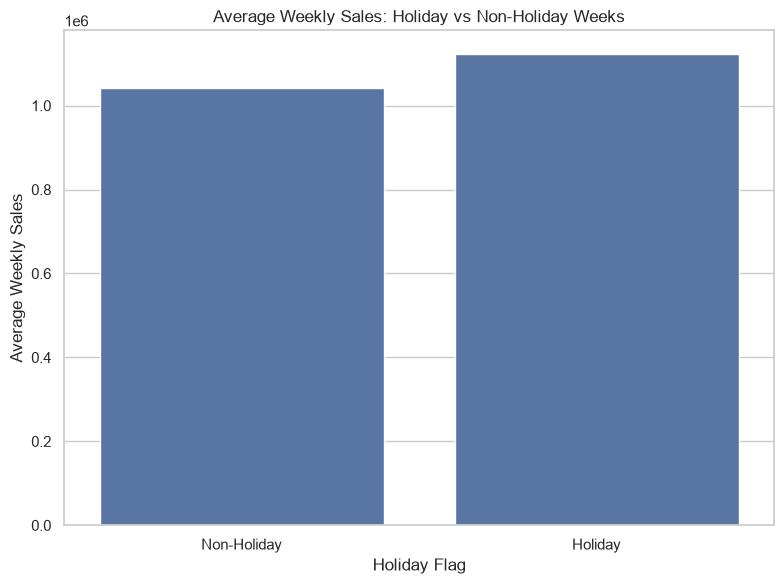

In [18]:
# Creating a chart

plt.figure(figsize=(8, 6))

sns.barplot(
    data=eda_df,
    x="holiday_flag",
    y="weekly_sales",
    estimator="mean",
    errorbar=None,
)

plt.title(
    "Average Weekly Sales: Holiday vs Non-Holiday Weeks"
)
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Holiday", "Holiday"],
)
plt.tight_layout()

plt.savefig(
    images_path / "holiday_vs_nonholiday_sales.png",
    bbox_inches="tight",
)

plt.show()

### Holiday and Non-Holiday Sales Interpretation

The analysis compares weekly sales during holiday weeks and non-holiday weeks.

The results show:

- **Non-holiday weeks:** 5,985 observations
- **Holiday weeks:** 450 observations
- **Average non-holiday weekly sales:** approximately **1,041,256**
- **Average holiday weekly sales:** approximately **1,122,888**
- **Median non-holiday weekly sales:** approximately **956,211**
- **Median holiday weekly sales:** approximately **1,018,538**

Holiday weeks have a higher average and median weekly sales value than non-holiday weeks.

The difference in average weekly sales is approximately **81,632**, which suggests that holiday periods are associated with stronger sales performance.

However, the total sales value for non-holiday weeks is much larger because there are far more non-holiday observations in the dataset. Therefore, total sales should not be used alone to compare the two groups.

The chart supports the summary table because the holiday bar is slightly higher than the non-holiday bar.

This suggests that `holiday_flag` contains useful predictive information and should be retained as a feature during model development.

Holiday weeks record approximately **7.8% higher average weekly sales** than non-holiday weeks.

The result indicates an association between holiday weeks and higher sales, but it does not prove that holidays alone caused the increase. Store differences, promotions, seasonal demand, and other factors may also contribute.

## Weekly Sales Trend Over Time

Sales are aggregated across all stores for each date to examine the overall direction and seasonal movement of Walmart sales.

In [19]:
# Creating the overall sales trend

weekly_total_sales = (
    eda_df
    .groupby("date", as_index=False)
    ["weekly_sales"]
    .sum()
    .sort_values("date")
)

weekly_total_sales.head()

,date,weekly_sales
0,2010-02-05,"49,750,740.50"
1,2010-02-12,"48,336,677.63"
2,2010-02-19,"48,276,993.78"
3,2010-02-26,"43,968,571.13"
4,2010-03-05,"46,871,470.30"


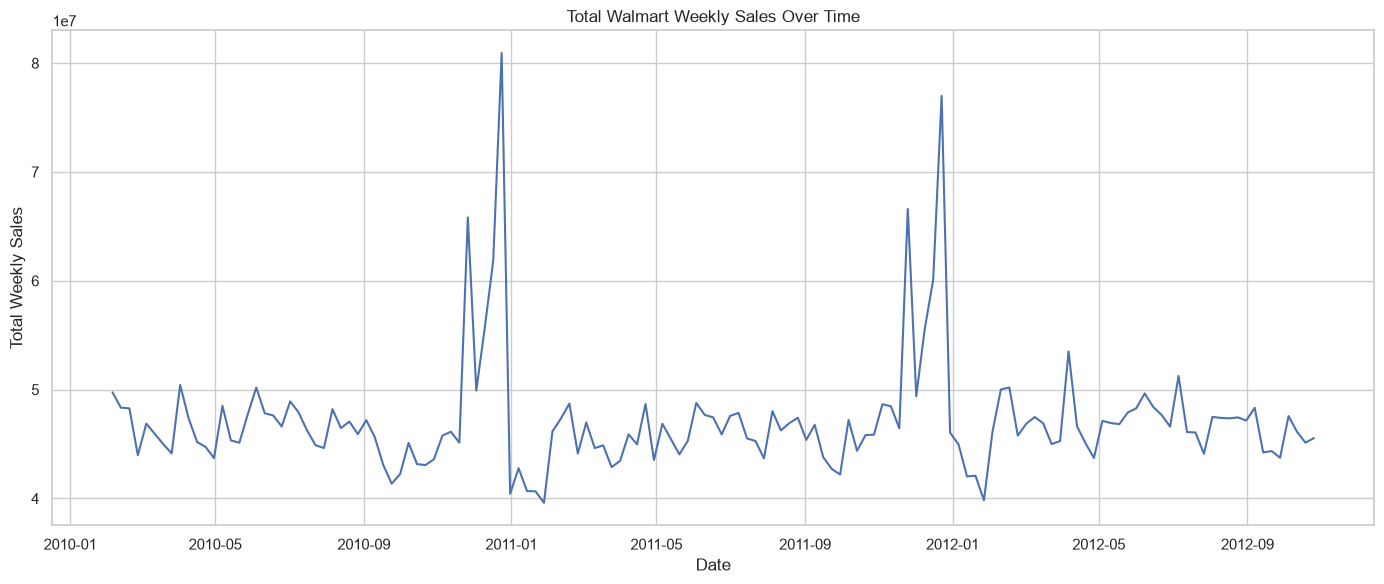

In [20]:
# Creating the line chart

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=weekly_total_sales,
    x="date",
    y="weekly_sales",
)

plt.title(
    "Total Walmart Weekly Sales Over Time"
)
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "weekly_sales_time_trend.png",
    bbox_inches="tight",
)

plt.show()

### Weekly Sales Trend Over Time Interpretation

The line chart shows total weekly sales aggregated across all Walmart stores from **February 2010 to October 2012**.

Most weeks remain within a relatively stable range of approximately **£40 million to £50 million** in total sales. However, several sharp peaks appear during specific periods.

The most noticeable sales spikes occur around the end of each year, especially near:

- Late 2010
- Late 2011

These peaks are likely connected to major holiday shopping periods, seasonal demand, promotional activity, and increased customer spending.

After each major peak, total weekly sales return quickly to their usual range. This suggests that the high values are temporary seasonal events rather than a permanent upward trend.

The chart does not show a strong long-term increase or decrease across the full period. Instead, the main pattern is repeated seasonal fluctuation with occasional large sales peaks.

This result suggests that:

- Date-related features are important for prediction.
- Holiday periods may strongly affect weekly sales.
- Month and week-of-year features should be created during feature engineering.
- A chronological train-test split should be used so that the model learns from earlier observations and is evaluated on later periods.

Overall, weekly sales appear to be influenced more by recurring seasonal events than by a simple continuous upward or downward trend.

## Average Weekly Sales by Year

Yearly comparison helps reveal whether average weekly sales changed across the available observation period.

In [21]:
# Examining yearly sales

yearly_sales = (
    eda_df
    .groupby("year", as_index=False)
    ["weekly_sales"]
    .mean()
)

yearly_sales

,year,weekly_sales
0,2010,"1,059,669.50"
1,2011,"1,046,239.32"
2,2012,"1,033,660.39"


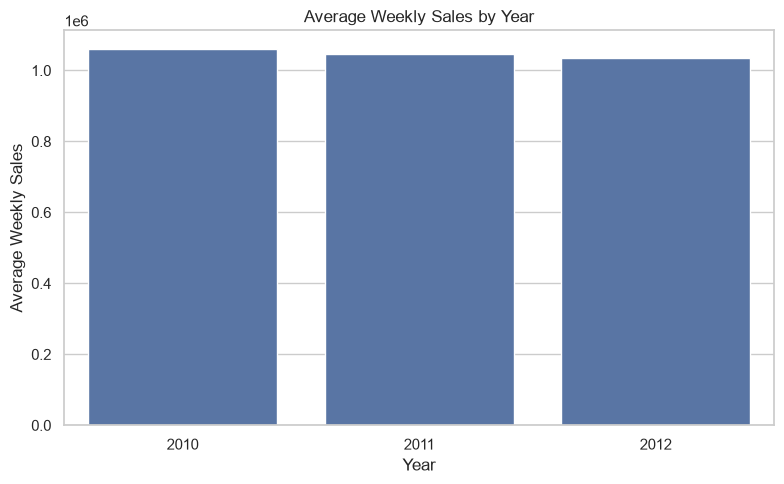

In [22]:
# Creating a chart

plt.figure(figsize=(8, 5))

sns.barplot(
    data=yearly_sales,
    x="year",
    y="weekly_sales",
)

plt.title(
    "Average Weekly Sales by Year"
)
plt.xlabel("Year")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "average_sales_by_year.png",
    bbox_inches="tight",
)

plt.show()

### Average Weekly Sales by Year Interpretation

The yearly comparison shows a small decline in average weekly sales across the available years.

The results are:

- **2010:** approximately **1,059,669.50**
- **2011:** approximately **1,046,239.32**
- **2012:** approximately **1,033,660.39**

Average weekly sales decreased by approximately **£13,430** from 2010 to 2011 and by approximately **12,579** from 2011 to 2012.

Overall, average weekly sales declined by about **£26,009** between 2010 and 2012, which represents a relatively small decrease of roughly **2.5%**.

The bar chart confirms this pattern, as each year is slightly lower than the previous year.

However, this result should be interpreted carefully because the dataset does not contain a complete set of observations for every year. The data begins in February 2010 and ends in October 2012, meaning that 2010 and 2012 are incomplete years.

Therefore, the apparent decline may partly reflect differences in the months included in each year rather than a true long-term reduction in sales.

The result suggests that the `year` feature may contain useful time-related information, but it should not be used alone. Month, week of year, holiday periods, and store identity should also be included during feature engineering.

## Monthly Sales Pattern

Monthly averages help reveal possible seasonality within the calendar year.

In [23]:
monthly_sales = (
    eda_df
    .groupby(
        ["month", "month_name"],
        as_index=False,
    )
    ["weekly_sales"]
    .mean()
    .sort_values("month")
)

monthly_sales

,month,month_name,weekly_sales
0,1,January,"923,884.55"
1,2,February,"1,053,199.80"
2,3,March,"1,013,309.23"
3,4,April,"1,026,761.56"
4,5,May,"1,031,714.02"
5,6,June,"1,064,324.59"
6,7,July,"1,031,747.58"
7,8,August,"1,048,017.45"
8,9,September,"989,335.35"
9,10,October,"999,632.12"


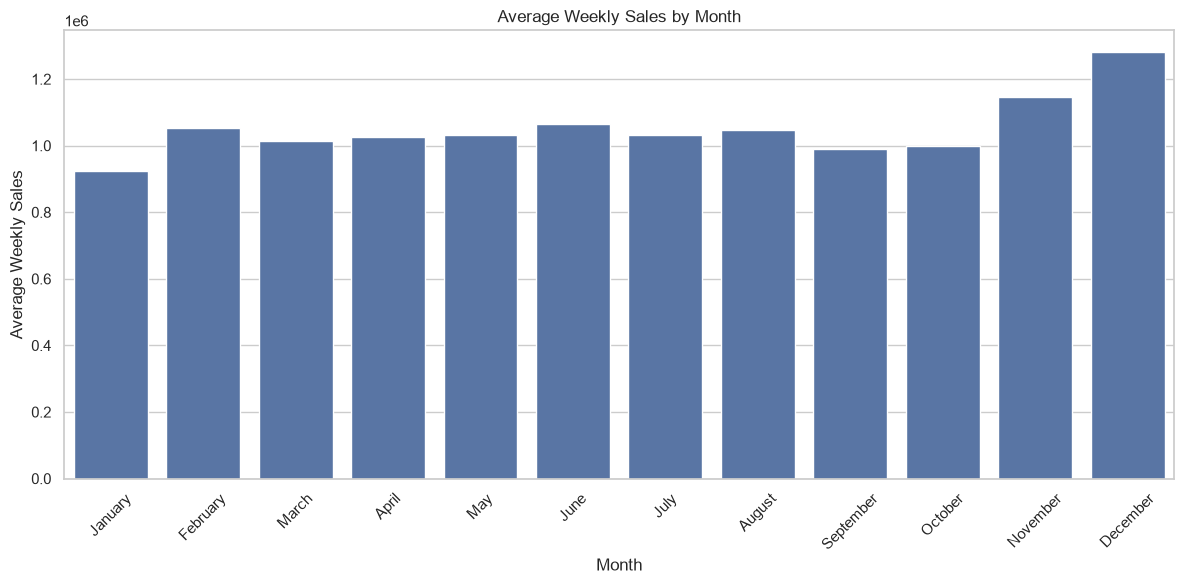

In [24]:
# Creating the chart

plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="month_name",
    y="weekly_sales",
    order=monthly_sales["month_name"],
)

plt.title(
    "Average Weekly Sales by Month"
)
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    images_path / "average_sales_by_month.png",
    bbox_inches="tight",
)

plt.show()

### Monthly Sales Pattern Interpretation

The monthly analysis shows that average weekly sales vary throughout the year, indicating the presence of seasonal sales patterns.

The highest average weekly sales occur in **December**, with an average of approximately **1,281,864**, making it the strongest sales month in the dataset.

**November** also records relatively high average sales (approximately **1,147,266**), suggesting that sales begin to increase before December.

Sales remain fairly stable between **February and August**, with average weekly sales generally ranging between **1.01 million and 1.06 million**.

The lowest average weekly sales occur in **January** (approximately **923,885**), followed by **September** (approximately **989,335**) and **October** (approximately **999,632**).

The noticeable increase in November and December is likely associated with major shopping events and holiday spending, while the lower sales in January may reflect reduced consumer spending after the holiday season.

Overall, the results indicate that **month is an important predictor of weekly sales** because sales fluctuate throughout the year rather than remaining constant. Therefore, the `month` feature should be retained during feature engineering to help the machine learning model capture seasonal patterns and improve prediction accuracy.

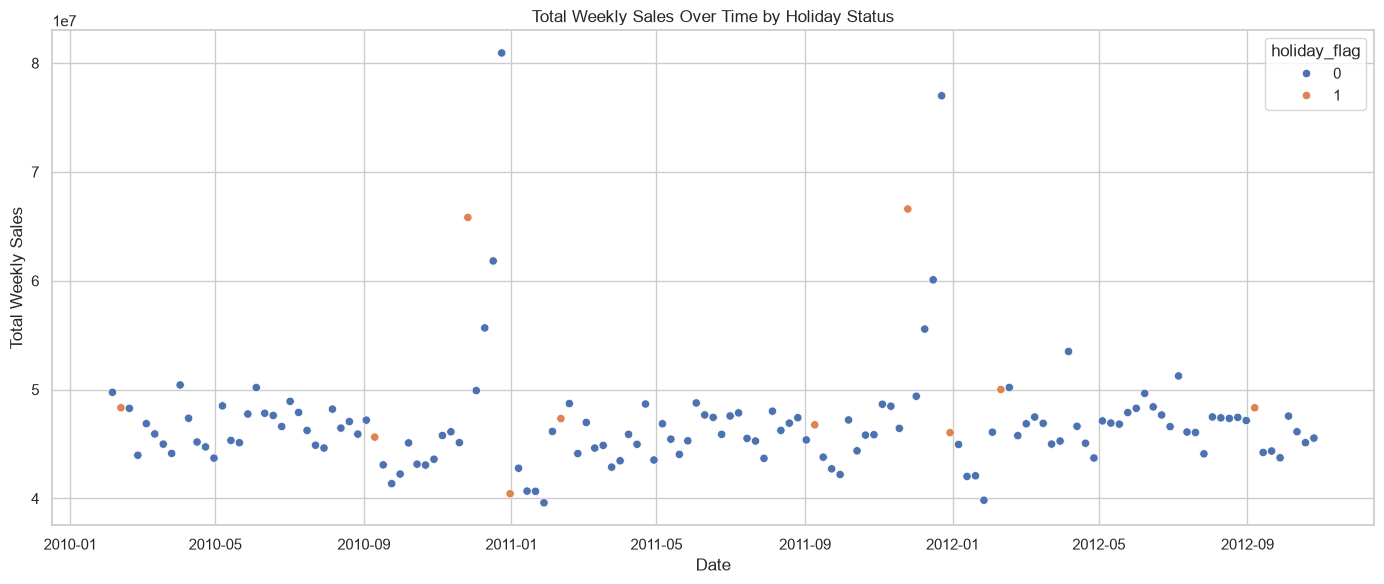

In [25]:
# Comparing sales by holiday across time

holiday_time_sales = (
    eda_df
    .groupby(
        ["date", "holiday_flag"],
        as_index=False,
    )
    ["weekly_sales"]
    .sum()
)

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=holiday_time_sales,
    x="date",
    y="weekly_sales",
    hue="holiday_flag",
)

plt.title(
    "Total Weekly Sales Over Time by Holiday Status"
)
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "sales_time_by_holiday.png",
    bbox_inches="tight",
)

plt.show()

### Weekly Sales Over Time by Holiday Status Interpretation

The scatterplot compares total weekly sales over time for holiday and non-holiday weeks.

Most non-holiday weeks are concentrated within a relatively stable range of approximately **40 million to 50 million** in total weekly sales.

Holiday weeks appear less frequently, but several of them are associated with noticeable sales increases. Some of the largest sales peaks in the dataset occur during holiday periods, particularly around the end of the year.

However, not every holiday week produces exceptionally high sales. Some holiday observations remain close to the normal weekly-sales range. This suggests that the effect of a holiday may depend on the specific holiday, the time of year, and customer-shopping behaviour.

The chart also shows that a small number of non-holiday weeks have high sales. Therefore, holiday status is important, but it does not explain all major sales peaks by itself.

Overall, the `holiday_flag` feature contains useful predictive information and should be retained during modelling. It should also be considered together with date-related features such as month, week of year, and year to capture seasonal sales behaviour more effectively.

## Numerical Feature Distributions

The distributions of temperature, fuel price, CPI, and unemployment are examined to understand their range, concentration, and possible skewness.

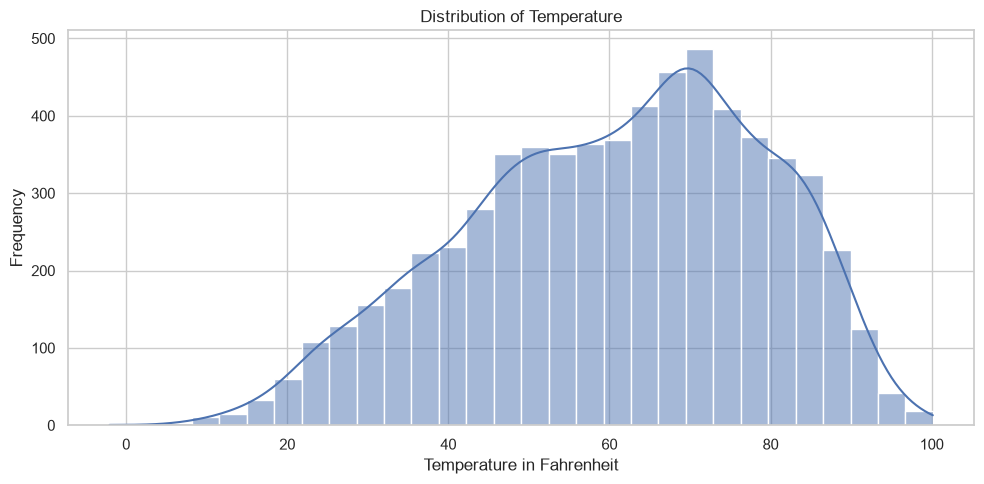

In [26]:
# Creating a Code cell for temperature

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="temperature",
    bins=30,
    kde=True,
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature in Fahrenheit")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    images_path / "temperature_distribution.png",
    bbox_inches="tight",
)

plt.show()

### Temperature Distribution Interpretation

The histogram shows the distribution of temperatures recorded across all stores and weeks.

Most temperature observations are concentrated between approximately **50°F and 80°F**, with the highest frequency occurring around **70°F**. This indicates that moderate to warm weather conditions were more common in the dataset.

Very low temperatures (below about 20°F) and very high temperatures (above about 90°F) occur much less frequently, showing that extreme weather conditions are relatively rare.

The distribution is **slightly left-skewed (negatively skewed)**, as the lower-temperature tail extends farther than the higher-temperature tail. This suggests that colder temperatures occur less frequently but are spread across a wider range.

Overall, temperature displays a reasonable spread without obvious abnormal values. Since weather conditions can influence customer shopping behaviour, the **temperature** feature may provide useful predictive information for the regression model and should be retained for model training.

### Remember: temperature is measured in Fahrenheit.

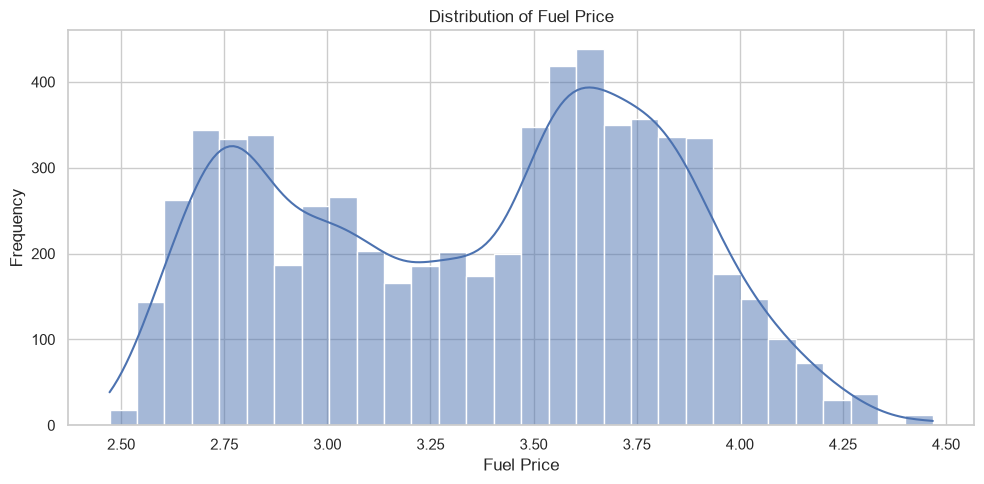

In [27]:
# Creating another code cell for fuel price

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="fuel_price",
    bins=30,
    kde=True,
)

plt.title("Distribution of Fuel Price")
plt.xlabel("Fuel Price")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    images_path / "fuel_price_distribution.png",
    bbox_inches="tight",
)

plt.show()

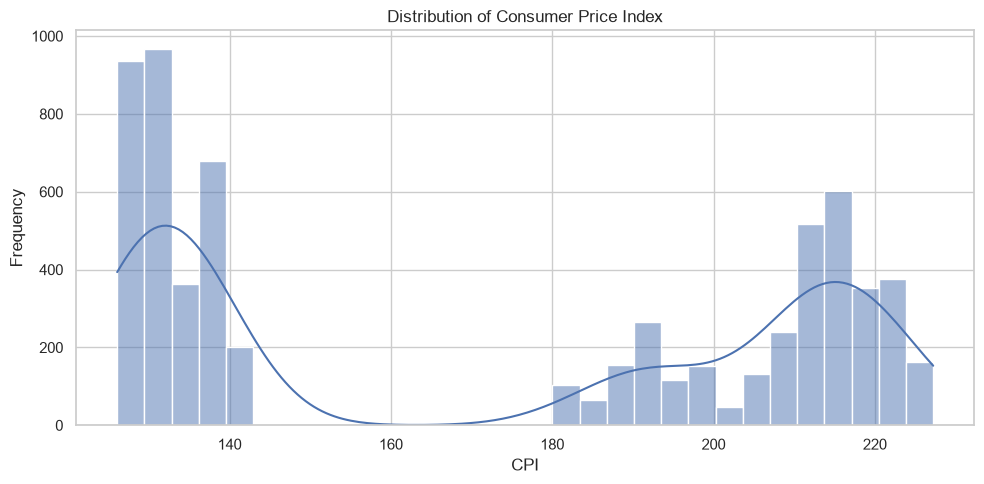

In [28]:
# Creating another for CPI

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="cpi",
    bins=30,
    kde=True,
)

plt.title("Distribution of Consumer Price Index")
plt.xlabel("CPI")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    images_path / "cpi_distribution.png",
    bbox_inches="tight",
)

plt.show()

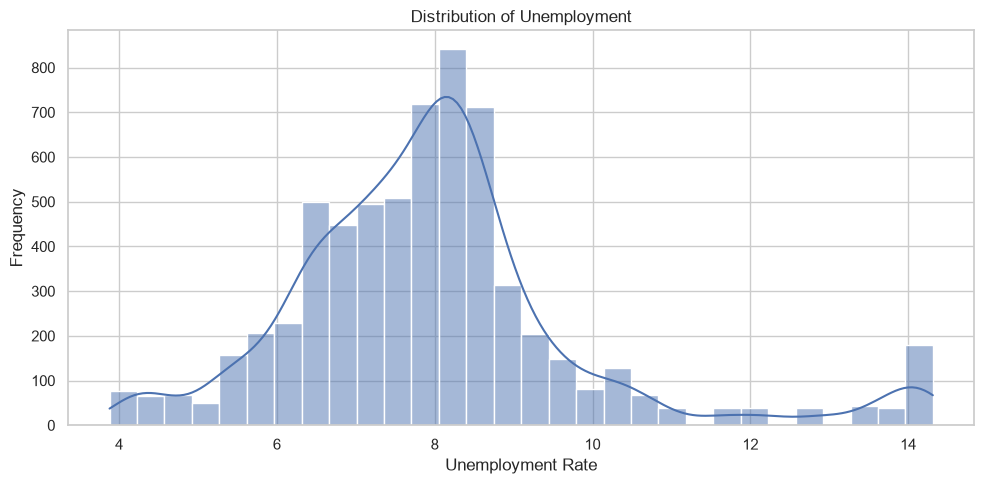

In [29]:
# Creating another for unemployment

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="unemployment",
    bins=30,
    kde=True,
)

plt.title("Distribution of Unemployment")
plt.xlabel("Unemployment Rate")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    images_path / "unemployment_distribution.png",
    bbox_inches="tight",
)

plt.show()

## Numerical Feature Distribution Interpretation

The distributions of **fuel price**, **Consumer Price Index (CPI)**, and **unemployment rate** were examined to understand their ranges, common values, and overall patterns before model training.

### Fuel Price

The fuel price distribution is **bimodal**, showing two clear peaks. One group of observations is concentrated around **2.7–3.0**, while another larger group is concentrated around **3.6–3.9**.

This pattern suggests that fuel prices changed over different periods of the dataset rather than remaining constant. The distribution does not indicate obvious extreme outliers, but instead reflects different pricing levels across time.

Since fuel costs can influence consumer purchasing behaviour and transportation expenses, **fuel price is expected to be a useful predictor of weekly sales**.

### Consumer Price Index (CPI)

The CPI distribution is also **bimodal**, with one cluster around **126–138** and another around **210–225**.

The gap between these clusters suggests that the dataset contains observations collected during different economic periods or regions with different CPI levels.

Although the distribution is not normally distributed, it does not contain unusual extreme values. CPI captures inflation and changes in purchasing power, making it an important economic indicator that may influence customer spending patterns.

### Unemployment Rate

The unemployment rate is concentrated mostly between **6% and 9%**, with the highest frequency occurring around **8%**.

The distribution is **positively skewed (right-skewed)** because a small number of observations extend toward higher unemployment rates above **10%**.

Most observations fall within a moderate unemployment range, while very high unemployment rates occur less frequently. These higher values appear to represent genuine economic conditions rather than data quality issues.

Since unemployment affects household income and consumer spending, it may contribute useful information when predicting weekly sales.

### Overall Interpretation

The numerical features exhibit different distribution patterns. Temperature is slightly left-skewed, fuel price and CPI are bimodal, while unemployment is positively skewed.

These distributions reflect realistic economic and environmental conditions rather than data errors. Therefore, all four numerical variables (**temperature, fuel price, CPI, and unemployment**) will be retained for feature engineering and model development, allowing the machine learning models to learn potential relationships between these factors and weekly sales.

## Temperature and Weekly Sales

A scatterplot is used to inspect whether weekly sales show a visible relationship with temperature.

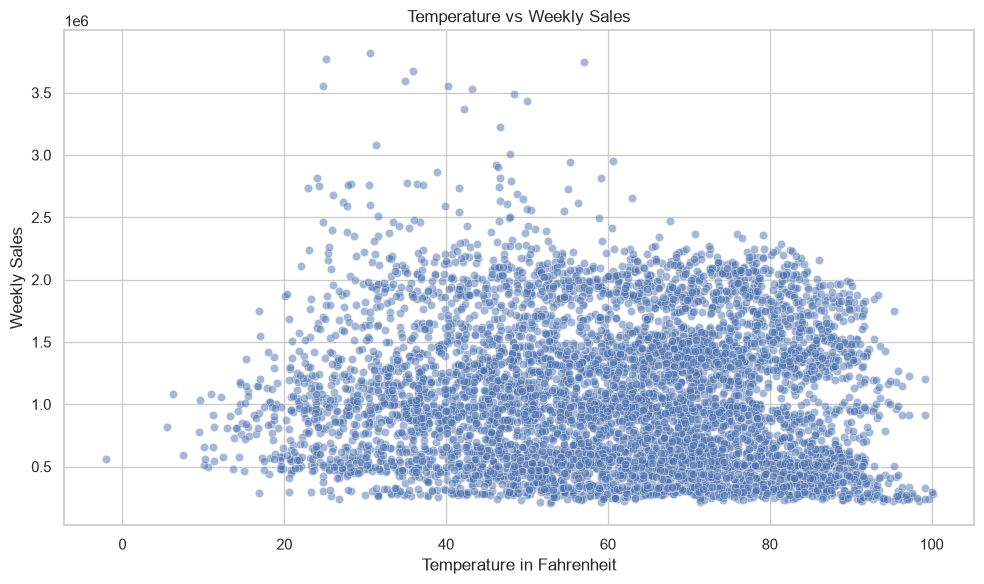

In [30]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="temperature",
    y="weekly_sales",
    alpha=0.5,
)

plt.title(
    "Temperature vs Weekly Sales"
)
plt.xlabel("Temperature in Fahrenheit")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "temperature_vs_sales.png",
    bbox_inches="tight",
)

plt.show()

## Temperature vs Weekly Sales Interpretation

The scatter plot was used to examine whether there is a relationship between **temperature** and **weekly sales**.

The observations are widely dispersed across the entire temperature range, indicating that **there is no strong linear relationship** between temperature and weekly sales.

Although a few weeks recorded exceptionally high sales, these occur at different temperatures rather than being concentrated within a specific temperature range. This suggests that high sales are likely influenced by other factors such as **holiday periods, promotions, store size, or economic conditions** instead of temperature alone.

Most observations are clustered below approximately **2 million weekly sales**, while only a small number of observations exceed this level. These higher values appear to represent genuine peak sales rather than data errors.

Overall, temperature alone does not appear to be a strong predictor of weekly sales. However, it may still contribute useful information when combined with other features in the regression model. Machine learning algorithms can capture interactions between temperature and other variables that may not be visible from this scatter plot alone.

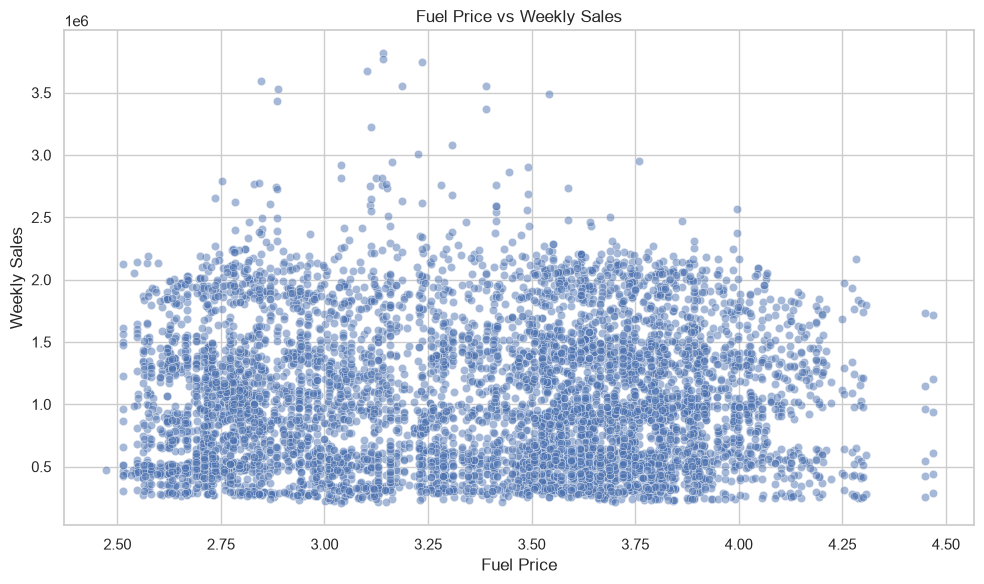

In [31]:
# Examining fuel price and weekly sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="fuel_price",
    y="weekly_sales",
    alpha=0.5,
)

plt.title(
    "Fuel Price vs Weekly Sales"
)
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "fuel_price_vs_sales.png",
    bbox_inches="tight",
)

plt.show()

## Fuel Price vs Weekly Sales Interpretation

The scatter plot was used to examine whether there is a relationship between **fuel price** and **weekly sales**.

The observations are widely scattered across the entire fuel price range (approximately **2.5 to 4.5**), indicating that there is **no strong linear relationship** between fuel price and weekly sales.

Weekly sales vary considerably at both low and high fuel prices, with similar sales values occurring across different fuel price levels. This suggests that changes in fuel prices alone do not consistently influence weekly sales.

A small number of observations represent exceptionally high weekly sales. These outliers occur at various fuel prices rather than at a specific price level, indicating that they are more likely associated with factors such as **holiday periods, promotional events, seasonal demand, or differences in store size** rather than fuel prices.

Overall, fuel price does not appear to be a strong standalone predictor of weekly sales. However, it may still provide useful information when combined with other explanatory variables in the regression model, where interactions between multiple features can improve prediction performance.

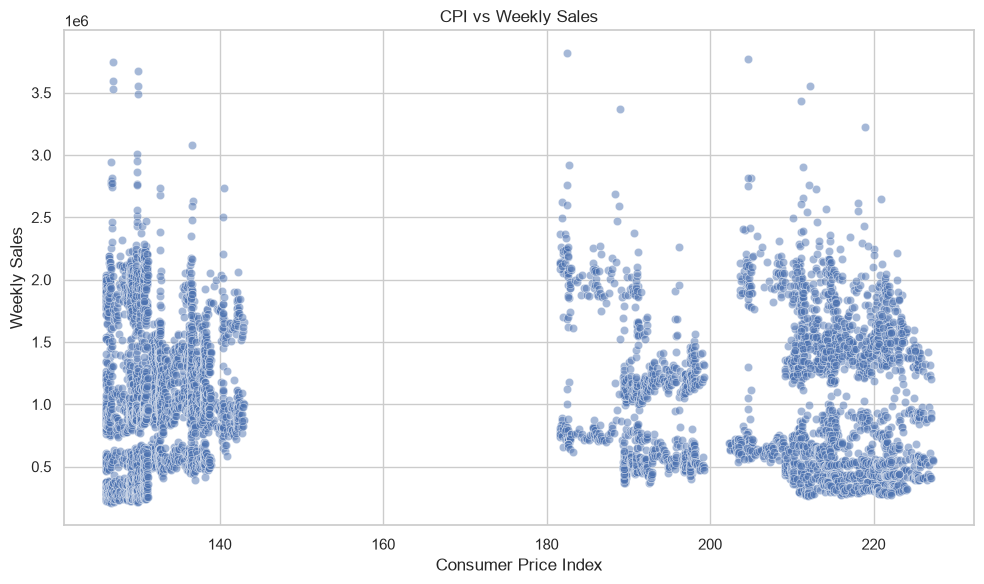

In [32]:
# Examining CPI and weekly sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="cpi",
    y="weekly_sales",
    alpha=0.5,
)

plt.title(
    "CPI vs Weekly Sales"
)
plt.xlabel("Consumer Price Index")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "cpi_vs_sales.png",
    bbox_inches="tight",
)

plt.show()

## CPI vs Weekly Sales Interpretation

The scatter plot was used to examine whether there is a relationship between the **Consumer Price Index (CPI)** and **weekly sales**.

The observations are widely dispersed across the different CPI values, with no clear upward or downward trend. This indicates that there is **no strong linear relationship** between CPI and weekly sales.

The plot shows two distinct clusters of CPI values, reflecting different economic periods or regions represented in the dataset. Despite these differences in CPI, weekly sales remain highly variable within each cluster, suggesting that similar sales levels occur across both low and high CPI values.

A few observations represent exceptionally high weekly sales. These outliers appear at several CPI levels rather than being concentrated at a particular CPI value, indicating that they are more likely associated with factors such as **holiday periods, promotional campaigns, seasonal demand, or differences in store size** than with changes in CPI.

Overall, CPI does not appear to be a strong standalone predictor of weekly sales. However, it may still contribute useful information when combined with other variables, such as **temperature, fuel price, unemployment, holiday status, and store characteristics**, within the regression model to improve prediction performance.

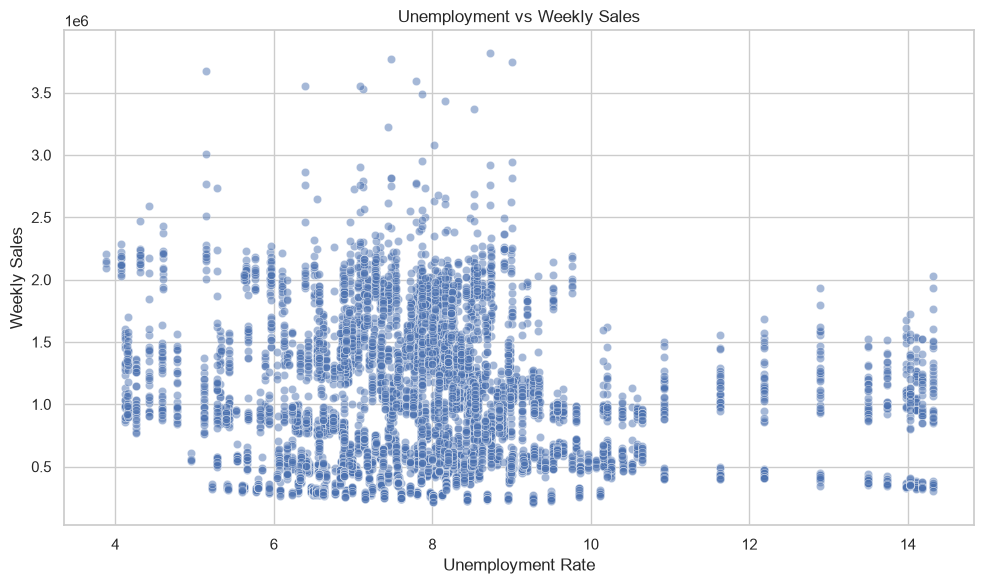

In [33]:
# Examining unemployment and weekly sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="unemployment",
    y="weekly_sales",
    alpha=0.5,
)

plt.title(
    "Unemployment vs Weekly Sales"
)
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.savefig(
    images_path / "unemployment_vs_sales.png",
    bbox_inches="tight",
)

plt.show()

## Unemployment vs Weekly Sales Interpretation

The scatter plot was created to examine whether there is a relationship between the **unemployment rate** and **weekly sales**.

The observations are widely scattered across different unemployment rates, with no clear upward or downward trend. This indicates that there is **no strong linear relationship** between unemployment and weekly sales.

Most observations are concentrated between **6% and 9% unemployment**, where weekly sales vary considerably from low to high values. This suggests that stores can experience both low and high sales even when unemployment rates are similar.

At higher unemployment rates (around **11% to 14%**), weekly sales are generally concentrated at lower to moderate levels, although a few higher sales values are still observed. This may indicate a slight tendency for sales to decrease as unemployment rises, but the relationship is weak and inconsistent.

Several observations represent exceptionally high weekly sales. These outliers occur across different unemployment levels rather than at one specific unemployment rate, suggesting that they are more likely influenced by **holiday periods, promotional events, seasonal demand, or store characteristics** than by unemployment alone.

Overall, unemployment does not appear to be a strong standalone predictor of weekly sales. However, it may still provide useful information when combined with other variables such as **temperature, fuel price, CPI, holiday status, and store characteristics** in the regression model, where the combined effect of multiple features can improve prediction accuracy.

## Correlation Analysis

Correlation measures the strength and direction of linear relationships between numerical variables.

Values range from:

- `+1`: strong positive linear relationship
- `0`: little or no linear relationship
- `-1`: strong negative linear relationship

Correlation does not prove causation.

In [34]:
# Creating a correlation matrix

correlation_columns = [
    "weekly_sales",
    "temperature",
    "fuel_price",
    "cpi",
    "unemployment",
]

correlation_matrix = (
    eda_df[correlation_columns]
    .corr()
)

correlation_matrix

,weekly_sales,temperature,fuel_price,cpi,unemployment
weekly_sales,1.00,-0.06,0.01,-0.07,-0.11
temperature,-0.06,1.00,0.14,0.18,0.10
fuel_price,0.01,0.14,1.00,-0.17,-0.03
cpi,-0.07,0.18,-0.17,1.00,-0.30
unemployment,-0.11,0.10,-0.03,-0.30,1.00


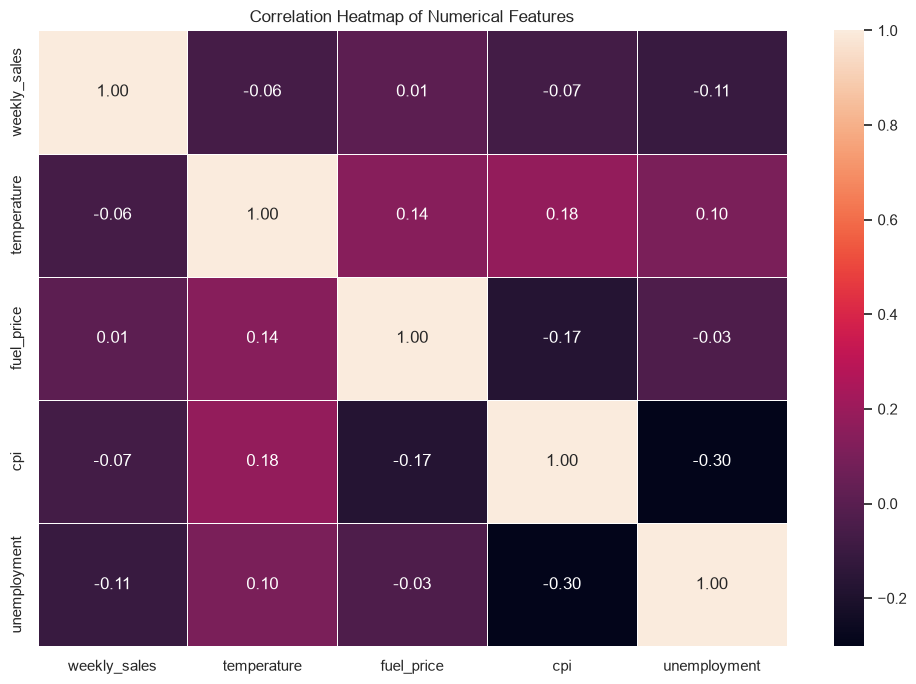

In [35]:
# Creating a heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)
plt.tight_layout()

plt.savefig(
    images_path / "correlation_heatmap.png",
    bbox_inches="tight",
)

plt.show()

## Correlation Analysis Interpretation

The correlation matrix and heatmap summarize the strength and direction of the linear relationships between the numerical variables in the Walmart sales dataset.

### Relationship with Weekly Sales (Target Variable)

The correlations between **weekly sales** and the other numerical features are all close to zero:

- **Temperature:** **-0.06**
- **Fuel Price:** **0.01**
- **CPI:** **-0.07**
- **Unemployment:** **-0.11**

These values indicate **very weak linear relationships** with weekly sales.

- **Temperature (-0.06):** There is a very weak negative relationship, suggesting temperature has little direct influence on weekly sales.
- **Fuel Price (0.01):** The correlation is almost zero, indicating virtually no linear relationship with weekly sales.
- **CPI (-0.07):** Consumer Price Index has a very weak negative relationship with weekly sales.
- **Unemployment (-0.11):** This is the strongest relationship with weekly sales among the numerical variables, but it is still weak and does not indicate a strong linear association.

Overall, none of the numerical variables individually appears to be a strong predictor of weekly sales based on linear correlation alone.

### Relationships Among Predictor Variables

The heatmap also shows the relationships between the independent variables:

- **Temperature and Fuel Price:** **0.14**
  - Weak positive relationship.

- **Temperature and CPI:** **0.18**
  - Weak positive relationship.

- **Temperature and Unemployment:** **0.10**
  - Very weak positive relationship.

- **Fuel Price and CPI:** **-0.17**
  - Weak negative relationship.

- **Fuel Price and Unemployment:** **-0.03**
  - Almost no relationship.

- **CPI and Unemployment:** **-0.30**
  - Moderate negative relationship.
  - As CPI increases, unemployment tends to decrease slightly in this dataset.

### Multicollinearity Assessment

None of the predictor variables has a correlation close to **±0.8** or **±0.9**, which are commonly used thresholds for identifying serious multicollinearity.

This suggests that the numerical features are **not highly correlated with one another**, meaning they can all be retained for model training without introducing significant multicollinearity issues.

### Overall Conclusion

The correlation analysis indicates that:

- Weekly sales do **not have a strong linear relationship** with temperature, fuel price, CPI, or unemployment individually.
- The numerical predictors also show **low to moderate correlations** with each other, indicating minimal multicollinearity.
- This suggests that weekly sales are likely influenced by the **combined effects of multiple variables**, including non-numerical features such as **store, department, holiday status, seasonal trends, and promotions**, rather than by any single numerical feature alone.
- Therefore, machine learning models that can learn interactions among multiple variables (such as **Random Forest**, **Gradient Boosting**, or **XGBoost**) may capture these complex relationships better than relying on simple linear correlations.

In [36]:
# Identifying correlations with the target

target_correlations = (
    correlation_matrix["weekly_sales"]
    .drop("weekly_sales")
    .sort_values(
        key=abs,
        ascending=False,
    )
)

target_correlations

unemployment   -0.11
cpi            -0.07
temperature    -0.06
fuel_price      0.01
Name: weekly_sales, dtype: float64

## Target Correlation Ranking Interpretation

The correlation values have been sorted according to their absolute magnitude to identify which numerical features have the strongest linear relationship with the target variable (**weekly_sales**).

| Feature | Correlation with Weekly Sales | Interpretation |
|---------|------------------------------:|---------------|
| Unemployment | **-0.11** | Weak negative relationship |
| CPI | **-0.07** | Very weak negative relationship |
| Temperature | **-0.06** | Very weak negative relationship |
| Fuel Price | **0.01** | Almost no linear relationship |

### Interpretation

The ranked correlations show that **unemployment** has the strongest linear relationship with weekly sales among the numerical variables, with a correlation coefficient of **-0.11**. However, this relationship is still very weak, indicating that changes in unemployment alone have little influence on weekly sales.

The **Consumer Price Index (CPI)** has a correlation of **-0.07**, while **temperature** has a correlation of **-0.06**. Both values are close to zero, suggesting only negligible negative linear relationships with weekly sales.

**Fuel price** has the smallest correlation (**0.01**), indicating virtually no linear relationship with weekly sales.

### Overall Finding

Although unemployment ranks as the strongest numerical predictor, **none of the numerical variables demonstrates a meaningful linear relationship with weekly sales**. Their correlation coefficients are all close to zero, meaning that no single numerical feature can adequately explain variations in weekly sales.

This finding suggests that weekly sales are likely influenced by a combination of multiple factors rather than a single numerical variable. Other features in the dataset, such as **store number, department, holiday status, seasonal effects, promotions, and interactions between variables**, are expected to contribute more to prediction performance.

Therefore, during model development, it is appropriate to include all relevant features and evaluate machine learning models capable of learning complex, non-linear relationships rather than relying solely on individual correlation values.

## Key Exploratory Findings

- Weekly sales vary substantially across stores and dates.
- The weekly-sales distribution contains a higher-value tail and possible outlier observations.
- Potential sales outliers may represent genuine holiday, seasonal, or high-store sales activity.
- Average weekly sales differ considerably across stores.
- Store identity is likely to be an important predictive feature.
- Holiday and non-holiday weeks show different sales behaviour.
- Total weekly sales fluctuate over time and contain noticeable peaks.
- Monthly and yearly patterns suggest time-related information may support prediction.
- Temperature is measured in Fahrenheit.
- Numerical economic features are measured on different scales.
- Individual economic variables may show weak linear correlations with weekly sales.
- Weak correlation does not rule out nonlinear or interaction effects.
- Calendar features should be created during feature engineering.
- A chronological split should be used for model evaluation.

## Business Insights

The exploratory analysis suggests that Walmart sales are influenced by a combination of store-level differences, time patterns, holidays, and external conditions.

From a business perspective:

- High-performing stores may require different inventory strategies from lower-performing stores.
- Seasonal and holiday peaks should be considered during staffing and stock planning.
- Sales forecasting should account for store identity rather than assuming that all stores behave similarly.
- Calendar patterns may help Walmart prepare for expected changes in customer demand.
- Economic variables should be evaluated alongside store and seasonal information rather than interpreted independently.

## Phase Conclusion

Exploratory Data Analysis was completed successfully using the cleaned Walmart sales dataset.

The analysis examined:

- Weekly-sales distribution
- Potential outliers
- Store-level performance
- Holiday effects
- Sales trends over time
- Monthly and yearly patterns
- Numerical feature distributions
- Relationships with weekly sales
- Correlations between numerical variables

The results show that store identity and time-related patterns are likely to be particularly important for sales prediction.

The next phase is **Feature Engineering**, where the project will:

- Create year, month, week, and seasonal features
- Define the target and predictor variables
- Separate feature types
- Prepare the dataset for chronological splitting
- Prevent data leakage

In [37]:
# Confirming that the charts were saved

saved_images = sorted(
    file.name
    for file in images_path.glob("*.png")
)

print(
    "Number of saved charts:",
    len(saved_images),
)

saved_images

Number of saved charts: 17


['average_sales_by_month.png',
 'average_sales_by_store.png',
 'average_sales_by_year.png',
 'correlation_heatmap.png',
 'cpi_distribution.png',
 'cpi_vs_sales.png',
 'fuel_price_distribution.png',
 'fuel_price_vs_sales.png',
 'holiday_vs_nonholiday_sales.png',
 'sales_time_by_holiday.png',
 'temperature_distribution.png',
 'temperature_vs_sales.png',
 'unemployment_distribution.png',
 'unemployment_vs_sales.png',
 'weekly_sales_boxplot.png',
 'weekly_sales_distribution.png',
 'weekly_sales_time_trend.png']